# L6. Lab: Teach a Device a New Object

The device learns a new object by writing example vectors to memory, no retraining and no fine-tuning. Show it something new, and seconds later it recognizes that object from a different angle.

## 1. An object-memory shard

In [1]:
import shutil
from pathlib import Path
from qdrant_edge import (
    EdgeShard, EdgeConfig, EdgeVectorParams, Distance,
    Point, UpdateOperation, Query, QueryRequest,
)
from helper import embed_image

SHARD_DIR = "./object_shard"
shutil.rmtree(SHARD_DIR, ignore_errors=True)
Path(SHARD_DIR).mkdir(parents=True, exist_ok=True)

config = EdgeConfig(
    vectors={
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)
RECOGNIZE_THRESHOLD = 0.80
print("Object shard ready. threshold =", RECOGNIZE_THRESHOLD)

Object shard ready. threshold = 0.8


## 2. Teach the objects it already knows

In [2]:
def teach(object_id, label, view_paths, start_id, note=None):
    vectors = embed_image(view_paths)
    points = [
        Point(
            id=start_id + i,
            vector={"image": vectors[i]},
            payload={"object_id": object_id, "label": label, "view_id": i,
                     **({"note": note} if note else {})},
        )
        for i in range(len(view_paths))
    ]
    shard.update(UpdateOperation.upsert_points(points))
    shard.optimize()


teach("lithops", "lithops (living stone)",
      ["../data/objects/lithops_1.jpg",
       "../data/objects/lithops_2.jpg"], start_id=0)
print("Known objects:", shard.info().points_count, "views")

Known objects: 2 views


## 3. Show it something new, not recognized yet

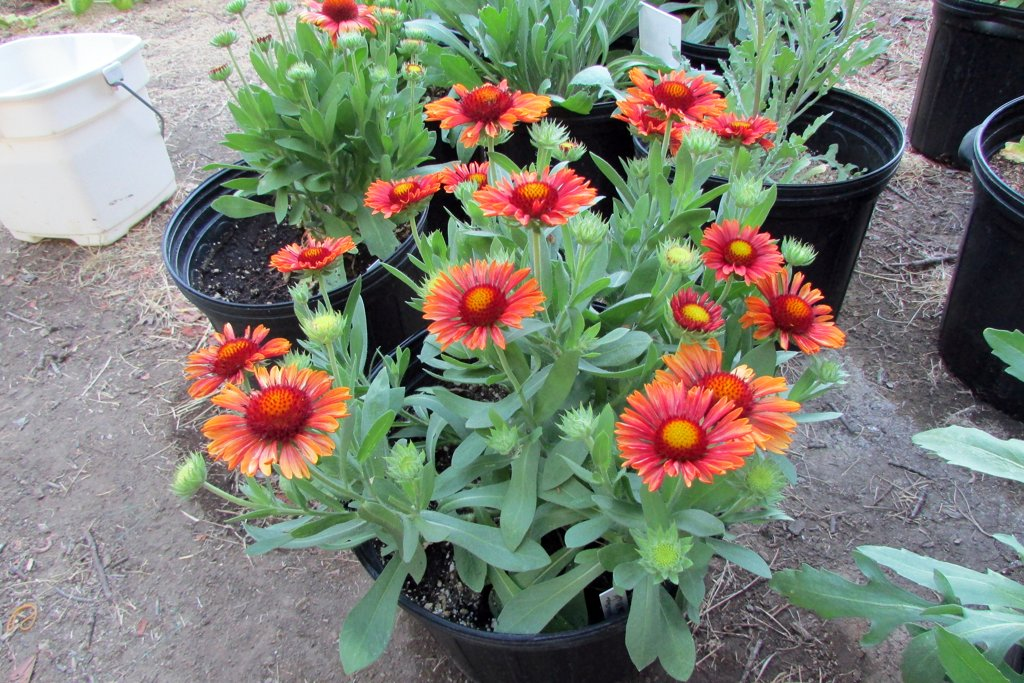

top score 0.609 vs threshold 0.8 -> UNKNOWN


In [3]:
from IPython.display import Image, display


def recognize(query_path, limit=1):
    query_vector = embed_image([query_path])[0]
    hits = shard.query(
        QueryRequest(
            query=Query.Nearest(query_vector, using="image"),
            limit=limit,
            with_payload=True,
        )
    )
    top = hits[0]
    return top, top.score >= RECOGNIZE_THRESHOLD, hits


query = "../data/objects/gaillardia_3.jpg"
top, known, _ = recognize(query)
display(Image(query, width=220))
verdict = top.payload["label"] if known else "UNKNOWN"
print(f"top score {top.score:.3f} vs threshold {RECOGNIZE_THRESHOLD} -> {verdict}")

## 4. Teach it the new object

In [4]:
# Give the new object a label, then teach two views.
my_label = "orange flower"
teach("flower_01", my_label,
      ["../data/objects/gaillardia_1.jpg",
       "../data/objects/gaillardia_2.jpg"], start_id=10)
print(f'Taught "{my_label}". Shard now holds', shard.info().points_count, "views")

Taught "orange flower". Shard now holds 4 views


## 5. The payoff: recognize it from a new angle

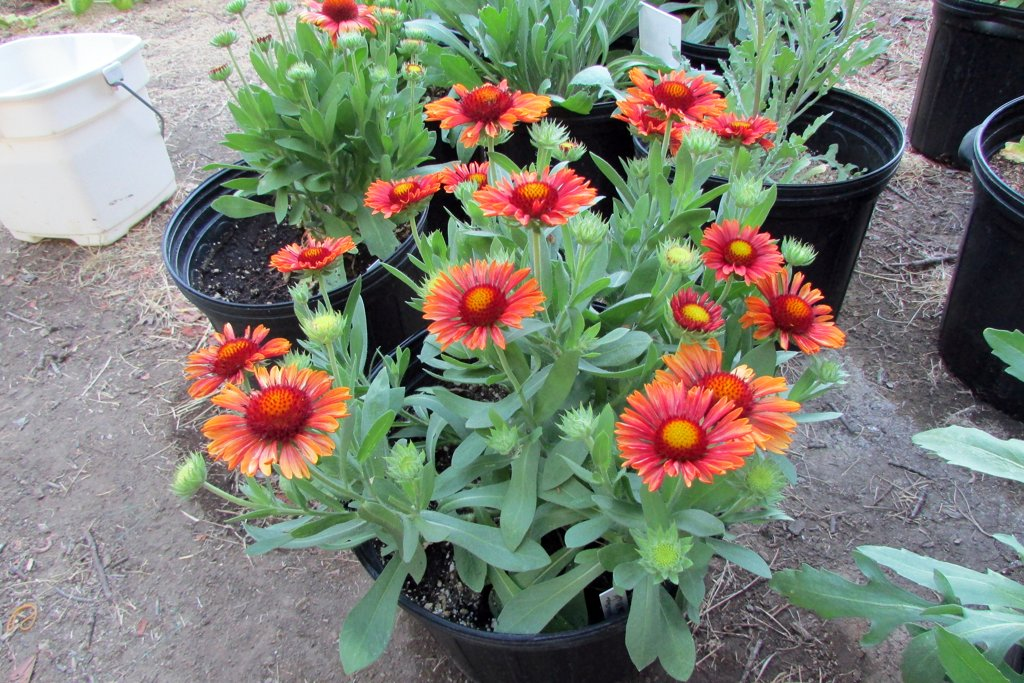

top score 0.903 -> orange flower
matched object_id=flower_01, view_id=0


In [5]:
top, known, _ = recognize(query)
display(Image(query, width=220))
verdict = top.payload["label"] if known else "UNKNOWN"
print(f"top score {top.score:.3f} -> {verdict}")
print(f"matched object_id={top.payload['object_id']}, view_id={top.payload['view_id']}")

## 6. Inspect the evidence and the threshold

In [6]:
print("gaillardia_3 (a view we never stored):")
for h in recognize(query, limit=3)[2]:
    p = h.payload
    print(f"  {h.score:.3f}  {p['label']} (view {p['view_id']})")

print(f"\n  --- threshold = {RECOGNIZE_THRESHOLD} ---\n")

print("never taught:")
for name in ["plant.jpg", "book.jpg", "coffee.jpg"]:
    t, _, _ = recognize(f"../data/images/{name}")
    print(f"  {t.score:.3f}  {name}")

gaillardia_3 (a view we never stored):
  0.903  orange flower (view 0)
  0.823  orange flower (view 1)
  0.609  lithops (living stone) (view 1)

  --- threshold = 0.8 ---

never taught:
  0.739  plant.jpg
  0.634  book.jpg
  0.562  coffee.jpg


## 7. The payoff: teach from the webcam

Point your camera at an object, capture a couple of views to teach it, then capture one more from a new angle to recognize it. No camera? Skip to the bundled fallback below, which does the same thing.

In [7]:
from helper import camera
recorder = camera()
recorder

ImageRecorder(image=Image(value=b''), stream=CameraStream(constraints={'video': True, 'audio': False}))

In [8]:
from helper import snapshot_to_file

# Click the camera's capture button above, then run this to teach a view.
try:
    path = snapshot_to_file(recorder, "./webcam_view1.jpg")
    teach("my_webcam_object", "my object", [path], start_id=200)
    print("Taught 1 webcam view. Capture a NEW angle, then run the next cell.")
except (AttributeError, RuntimeError) as e:
    print("No webcam capture yet:", e)
    print("No camera? Use the bundled version in section 8.")

No webcam capture yet: No snapshot yet: click the camera's capture button, then re-run.
No camera? Use the bundled version in section 8.


In [9]:
try:
    query_path = snapshot_to_file(recorder, "./webcam_query.jpg")
    top, known, _ = recognize(query_path)
    display(Image(query_path, width=220))
    print(f"{top.score:.3f} -> {top.payload['label'] if known else 'UNKNOWN'}")
except (AttributeError, RuntimeError) as e:
    print("No webcam capture yet:", e)

No webcam capture yet: No snapshot yet: click the camera's capture button, then re-run.


## 8. Bundled fallback: teach and recognize without a camera

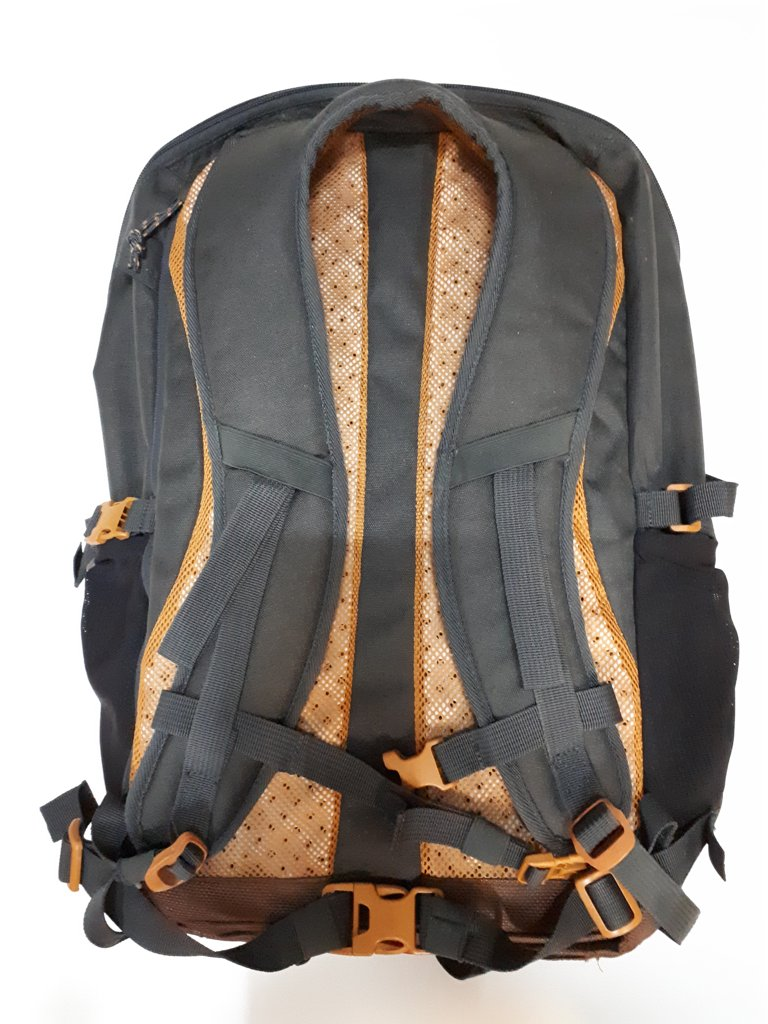

0.863 -> backpack


In [10]:
# A single example is enough: teach one view, recognize another.
teach("backpack", "backpack",
      ["../data/objects/backpack_1.jpg"], start_id=100,
      note="Quechua daypack, bought at SportsWorld, $45")
top, known, _ = recognize("../data/objects/backpack_2.jpg")
display(Image("../data/objects/backpack_2.jpg", width=220))
print(f"{top.score:.3f} -> {top.payload['label'] if known else 'UNKNOWN'}")

## 9. The payoff: everything you built, on one device

In [11]:
import json
from helper import (
    embed_text, embed_query, embed_query_clip, memory_inbox, cleanup,
)

cleanup(shard, "./object_shard")

SHARD_DIR = "./assistant_shard"
shutil.rmtree(SHARD_DIR, ignore_errors=True)
Path(SHARD_DIR).mkdir(parents=True, exist_ok=True)

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)

day = json.load(open("../data/memories.json"))
history = json.load(open("../data/recent_days.json"))
notes = [m for m in day + history if m["source_type"] in ("text", "voice")]
photos = [m for m in day if m["source_type"] == "photo"]

text_vectors = embed_text([m.get("note") or m["transcript"] for m in notes])
shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"text": text_vectors[i]}, payload=m)
    for i, m in enumerate(notes)
]))
image_vectors = embed_image([f"../data/images/{m['file']}" for m in photos])
shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"image": image_vectors[i]}, payload=m)
    for i, m in enumerate(photos)
]))

teach("backpack", "backpack",
      ["../data/objects/backpack_1.jpg"], start_id=5000,
      note="Quechua daypack, bought at SportsWorld, $45")

print(shard.info().points_count,
      "memories: a day of captures, weeks of notes, one taught object")

145 memories: a day of captures, weeks of notes, one taught object



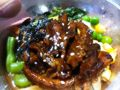

In [12]:
def recall(question, limit=3):
    text_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query(question), using="text"),
            limit=limit,
            with_payload=True,
        )
    )
    image_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query_clip(question), using="image"),
            limit=limit,
            with_payload=True,
        )
    )
    return {
        "Photos": [h for h in image_hits
                   if h.payload.get("source_type") == "photo"][:1],
        "Voice Notes": [h for h in text_hits
                        if h.payload.get("source_type") == "voice"],
        "Text Notes": [h for h in text_hits
                       if h.payload.get("source_type") == "text"],
    }


hits = recall("the ramen place downtown")
memory_inbox(hits, "../data/images")

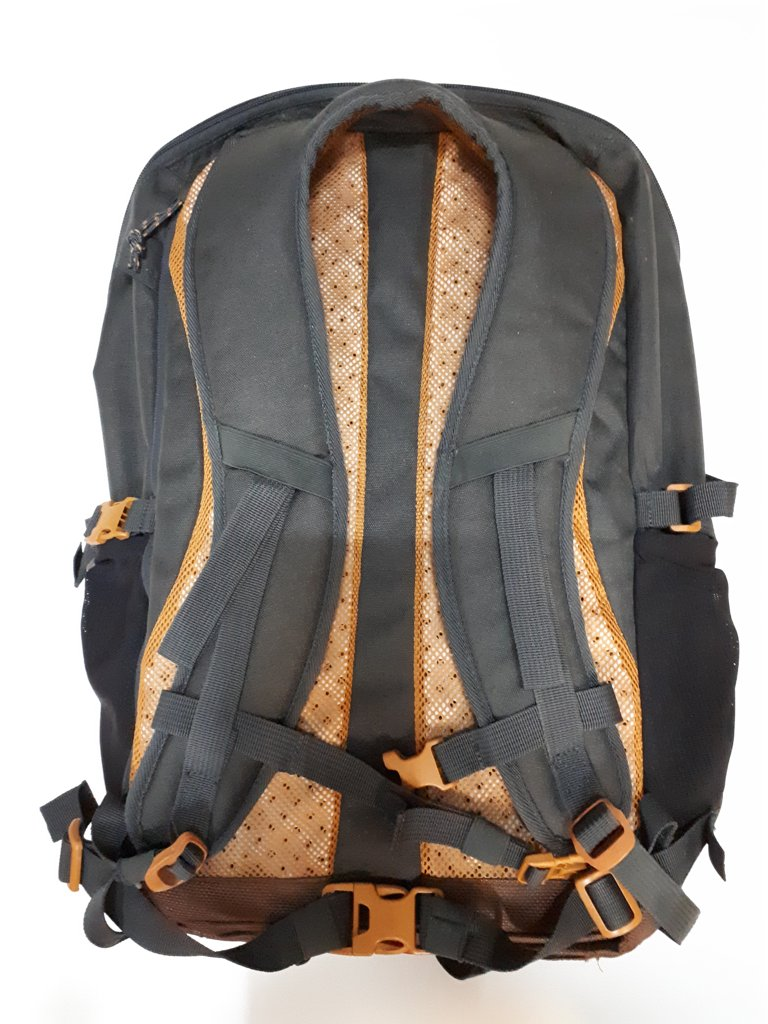

Recognized: backpack
I remember this: Quechua daypack, bought at SportsWorld, $45


In [13]:
top, known, _ = recognize("../data/objects/backpack_2.jpg")
display(Image("../data/objects/backpack_2.jpg", width=220))
if known:
    print(f"Recognized: {top.payload['label']}")
    print(f"I remember this: {top.payload['note']}")
else:
    print("UNKNOWN")

## 10. Wrap: it all persists, offline

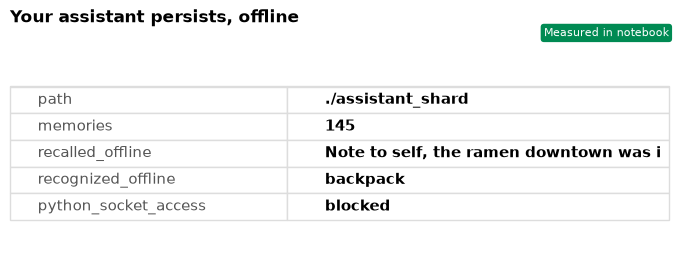

In [14]:
from helper import no_network, receipt_table

before = shard.info().points_count
shard.close()
with no_network():
    shard = EdgeShard.load("./assistant_shard")
    hits = recall("the ramen place downtown")
    top, known, _ = recognize("../data/objects/backpack_2.jpg")

receipt_table([
    ("path", "./assistant_shard"),
    ("memories", before),
    ("recalled_offline", hits["Voice Notes"][0].payload["transcript"][:38]),
    ("recognized_offline", top.payload["label"] if known else "UNKNOWN"),
    ("python_socket_access", "blocked"),
], title="Your assistant persists, offline")

In [15]:
cleanup(shard, "./assistant_shard")
for f in ["webcam_view1.jpg", "webcam_query.jpg"]:
    Path(f).unlink(missing_ok=True)
print("Cleaned up")

Cleaned up
